In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
import package_lab
from package_lab import LL_RT, PID_RT, Margin , IMCTuning

import os
import datetime as datetime
from datetime import datetime
import tclab
import time

# Simulation Parameters

In [2]:
TSim = 4000
Ts = 1
N = int(TSim/Ts) + 1

#Working point
MV0 = 50
DV0 = 50
PV0 = 67.8

#Process
#In-Out Dynamics
Kp = 0.399
T1p = 141.191
T2p = 25.927
thetap = 12.994
gamma = 0.9

#Disturbance Dynamics
Kd = 0.421
T1d = 159.476
T2d = 17.614
thetad = 6.459

#IMC tuning
Kc, Ti, Td= IMCTuning(Kp, T1p, T2p, thetap, gamma, process='SOPDT')
#Kc, Ti, Td= IMCTuning(Kp, T1, T2, theta, gamma, process='FOPDT_PID')
#Kc, Ti, Td= IMCTuning(Kp, T1, T2, theta, gamma, process='FOPDT_PI')

#Results print
print("Parametres PID via IMC (SOPDT):")
print("Kc =", round(Kc, 3))
print("Ti =", round(Ti, 3), "s")
print("Td =", round(Td, 3), "s")

alpha = 1
MVmin = 0
MVmax = 100

Parametres PID via IMC (SOPDT):
Kc = 2.99
Ti = 167.118 s
Td = 21.905 s


Simulation input signals

In [3]:
scenario = "CLP+FF"

# # Scenario 1: OLP + no FF
if scenario == "OLP+noFF":
    ManPath = {0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath = {0: PV0, TSim: PV0}
    DVPath = {0: 50, 1000: 60, TSim: 60}
    ActivateFF = False
    ManFF = True

## Scenario 2: OLP + FF
if scenario == "OLP+FF":
    ManPath ={0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath ={0: PV0, TSim: PV0}
    DVPath = {0: 50.0, 1000: 60, TSim: 60.0}
    ActivateFF = True
    ManFF = True

## Scenario 3: CLP + no FF
if scenario == "CLP+noFF":
    ManPath = {0: True, 500: False, TSim: False} 
    MVManPath = {0: MV0+10, TSim: MV0+10} 
    SPPath = {0: PV0+5, 1200: PV0-5, TSim: PV0-5} 
    DVPath = {0: DV0, 1800: DV0+10, TSim: DV0+10}
    ActivateFF = False
    ManFF = False

# # Scenario 4: CLP + FF
if scenario == "CLP+FF":
    ManPath = {0: True, 500: False, TSim: False} 
    MVManPath = {0: MV0+10, TSim: MV0+10} 
    SPPath = {0: PV0+5, 1200: PV0-5, TSim: PV0-5} 
    DVPath = {0: DV0, 1800: DV0+10, TSim: DV0+10}
    ActivateFF = True
    ManFF = False

Simulation with PID and FF

In [4]:
t = []
SP = []
MV = []
Man = []
MVMan = []
MVFF = []
MVP = []
MVI = []
MVD = []
DV = []
PV = []
E = []

MVFFDelay = []
MVFFLL1 = []

MVDelayp = []
PV1p = []
PV2p = []

MVDelayd = []
PV1d = []
PV2d = []

now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")

for i in range(0, N):
    t.append(i*Ts)
    
    # Inputs SP, DV
    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(DVPath, t, DV)
    
    
    # Feedforward   schema en vert
    Delay_RT(DV - DV0*np.ones_like(DV), np.max([thetad-thetap, 0]), Ts, MVFFDelay)
    LL_RT(MVFFDelay, -Kd/Kp, T1p, T1d, Ts, MVFFLL1)
    if ActivateFF:
        LL_RT(MVFFLL1, 1, T2p, T2d, Ts, MVFF)
    else:
        LL_RT(MVFFLL1, 0, T2p, T2d, Ts, MVFF)



    # PID control action
    #mode
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath, t, MVMan)
    
    # action
    
    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVmin, MVmax, MV, MVP, MVI, MVD, E, ManFF=False, PVinit=PV0, method='EBD-EBD')

    
    
    
    # Input-output dynamics P(s)
    Delay_RT(MV, thetap, Ts, MVDelayp,MV0)
    FO_RT(MVDelayp, Kp, T1p, Ts, PV1p,0)
    FO_RT(PV1p,1 ,T2p, Ts, PV2p, 0)       
    
    
    
    # Disturbance dynamics D(s)
    Delay_RT(DV - DV0*np.ones_like(DV), thetad, Ts, MVDelayd, 0)
    FO_RT(MVDelayd, Kd, T1d, Ts, PV1d,0)
    FO_RT(PV1d,1,T2d, Ts, PV2d, 0)
    
    
    PV.append(PV2p[-1]+ PV2d [-1]+ PV0 - Kp*MV0) 

Plot data

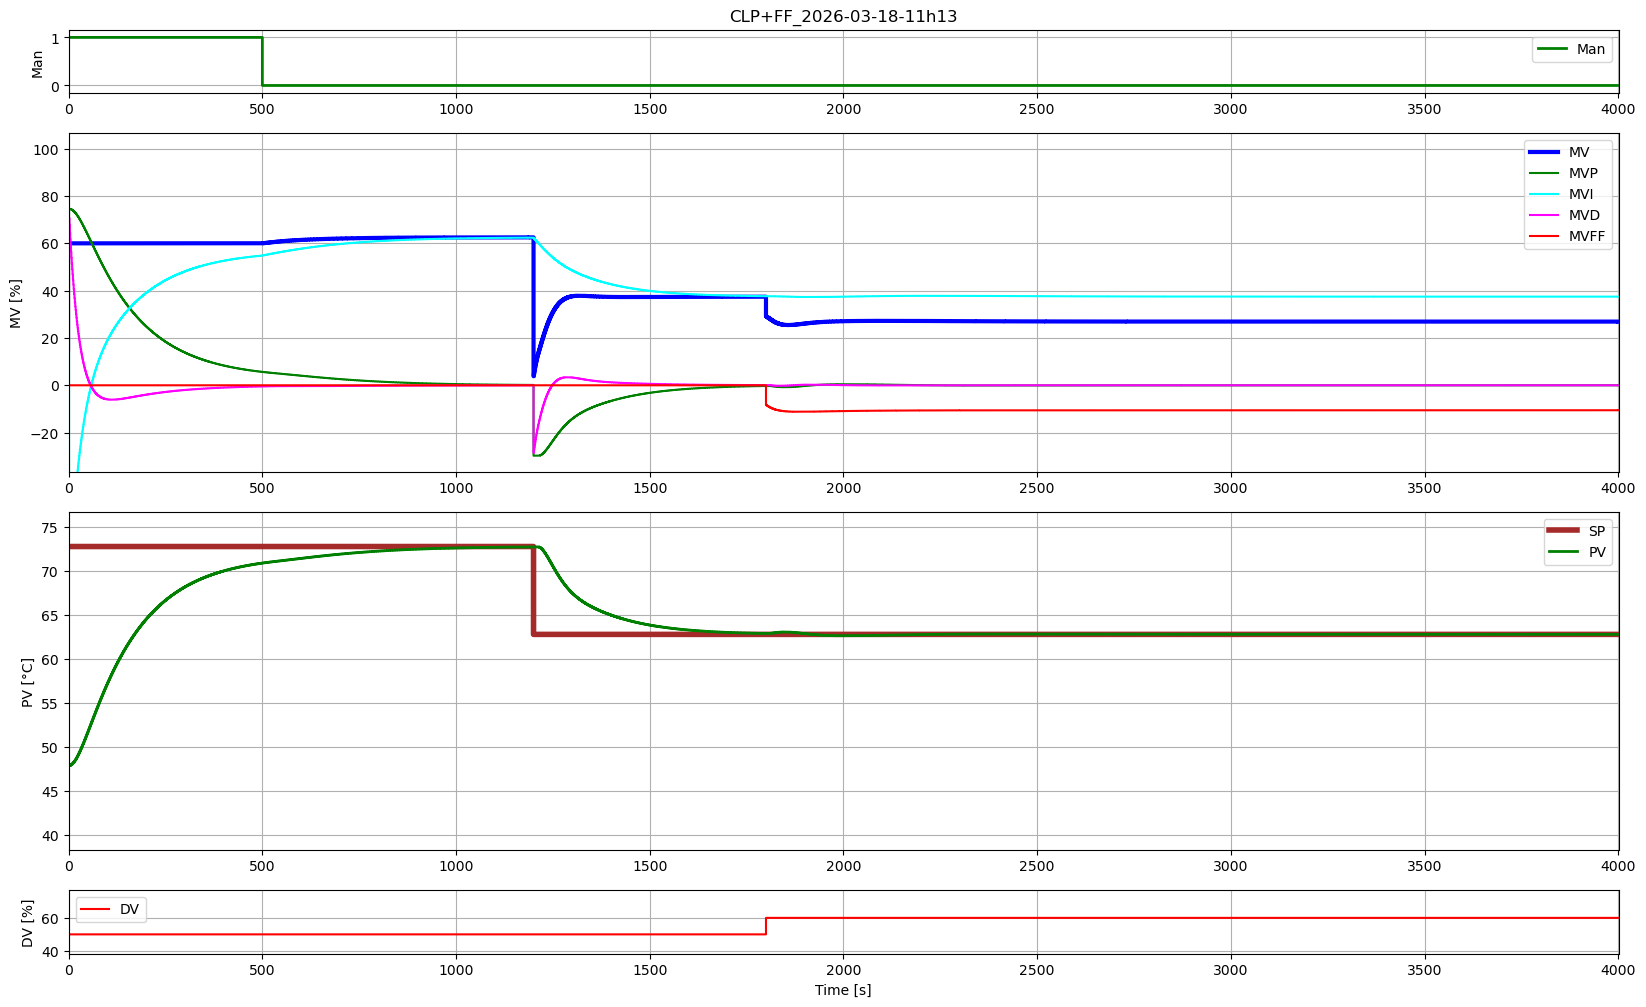

In [5]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, gridspec_kw={'height_ratios': [1.5, 8, 8, 1.5]})
fig.set_figheight(12)
fig.set_figwidth(20)

#ax1.set_title('PID_CLP_with_FF')
ax1.set_title(scenario + '_' + date_time)

#------MAN--------

limSup = 1.1
limInf = -0.1
l1, = ax1.step([0,TSim], [limInf,limSup], 'green',linewidth=2, label='Man', where="post")
ax1.set_ylabel('Man')
ax1.legend (loc='best')

#-------MV_MVP_MVI_MVD_MVFF--------------
limSup = 100
limInf = -30
l2, = ax2.step([0, TSim], [limInf,limSup], 'blue', linewidth=3, label='MV', where='post') 
l3, = ax2.step([0, TSim], [limInf,limSup], 'green', label='MVP', where='post') 
l4, = ax2.step([0, TSim], [limInf,limSup], 'cyan', label='MVI', where='post')
l5, = ax2.step([0, TSim], [limInf,limSup], 'magenta', label='MVD', where='post')
l6, = ax2.step([0, TSim], [limInf,limSup], 'red', label='MVFF', where='post') 
ax2.set_ylabel('MV [%]')
ax2.legend (loc='best')


#----SP_and_PV---------
limSup = 75
limInf = 40
l7, = ax3.step([0, TSim], [limInf,limSup], 'brown', linewidth=4, label='SP', where="post")
l8, = ax3.step([0, TSim], [limInf,limSup], 'green', linewidth=2, label='PV', where='post')
ax3.set_ylabel('PV [°C]')
ax3.legend (loc='best')


#-------DV-------------
limSup=75
limInf = 40
l9, = ax4.step([0, TSim], [limInf,limSup], 'red', label='DV', where='post')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('DV [%]')
ax4.legend (loc='best')


#-----Set Data-----
l1.set_data(t, Man)

l2.set_data(t,MV)
l3.set_data(t, MVP)
l4.set_data(t,MVI)
l5.set_data(t, MVD)
l6.set_data(t, MVFF)

l7.set_data(t, SP)
l8.set_data(t, PV)

l9.set_data(t, DV)

tMax = len(t)

ax1.set_xlim(0, tMax)
ax2.set_xlim(0, tMax)
ax3.set_xlim(0, tMax)
ax4.set_xlim(0, tMax)

ax1.grid()
ax2.grid()
ax3.grid()
ax4.grid()

#plt.savefig("imagesC/LP_output_plot.png", dpi=300, bbox_inches='tight')

# Save Plot
# ---------
if not os.path.exists('Plots'):
    os.makedirs('Plots')

nameFile = 'Plots/Simulation_' + scenario + '_' + date_time
plt.savefig(nameFile + '.png',transparent=True)            
plt.savefig(nameFile + '.pdf',transparent=True)